# 09_01 - biweekly 31.03

## Column reference (AGENTS.md)

| Use case | Real sources | Null sources |
|---|---|---|
| Total Vg | `vg_predicted` | `vg_predicted_perm` |
| Common AF Vg | `vg_common` | `vg_common_perm` |
| Rare AF Vg | `vg_rare` | `vg_rare_perm` |
| Spatial regions | `vg_{window}` | `vg_{window}_perm` |

> `vg_predicted_perm_sanity` is **not** used here — QC use only.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [11]:
from config import (
    GENE_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
    VG_LOG_SCALE,
    VG_MIN_CLIP,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '02_vg_log_scale'


def clip_for_log(vals: np.ndarray, clip: float = VG_MIN_CLIP) -> np.ndarray:
    """clip non-positive values before log transform.

    args:
        vals (np.ndarray): values to prepare for log scaling.
        clip (float): minimum positive replacement value.

    returns:
        np.ndarray: array safe for log scaling.
    """
    vals = np.asarray(vals)
    return np.where(vals <= 0, clip, vals)


print(f'VG_LOG_SCALE = {VG_LOG_SCALE}  (set in config.py)')
print(f'VG_MIN_CLIP  = {VG_MIN_CLIP}   (floor before log-transform)')
print('\nDatasets:')
for name in ['clingen', 'background', 'clingen_null', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')

VG_LOG_SCALE = True  (set in config.py)
VG_MIN_CLIP  = 1e-12   (floor before log-transform)

Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [12]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [13]:
print('df_real columns:', sorted(df_real.columns))
print('df_synth columns:', sorted(df_synth.columns))

candidate_cols = [
    c for c in df_real.columns
    if any(k in c.lower() for k in ['af', 'vg', 'promoter', 'upstream', 'downstream', 'tss', 'region'])
]
print('\nCandidate columns in df_real:')
for c in sorted(candidate_cols):
    print(' ', c)

for col in ['vg_predicted', 'vg_common', 'vg_rare', 'n_variants_common', 'n_variants_rare']:
    if col in df_real.columns:
        print(f"\n{col} summary:")
        print(
            df_real.select(
                pl.col(col).drop_nans().drop_nulls().alias(col)
            ).to_pandas()[col].describe(percentiles=[0.25, 0.5, 0.75])
        )

df_real columns: ['Episcore', 'N85', 'N90', 'RVIS_score', 'af_gradient', 'chrom', 'coding_length', 'cv_effect_N90', 'depletion_common', 'depletion_distal_upstream', 'depletion_down_distal', 'depletion_down_proximal', 'depletion_high_impact', 'depletion_promoter_core', 'depletion_proximal_upstream', 'depletion_rare', 'enrich_vg_distal_upstream', 'enrich_vg_down_distal', 'enrich_vg_down_proximal', 'enrich_vg_promoter_core', 'enrich_vg_proximal_upstream', 'entropy_distal_upstream', 'entropy_down_distal', 'entropy_down_proximal', 'entropy_effect', 'entropy_promoter_core', 'entropy_proximal_upstream', 'exonic_length', 'frac_high_impact_05', 'frac_high_impact_10', 'gene_id', 'gene_symbol', 'gene_type', 'genomic_length', 'intronic_length', 'is_mane', 'loeuf_score', 'mane_transcript_id', 'max_abs_effect', 'max_dist_to_tss', 'max_variant_id', 'max_variant_score', 'mean_abs_distal_upstream', 'mean_abs_down_distal', 'mean_abs_down_proximal', 'mean_abs_effect', 'mean_abs_promoter_core', 'mean_abs_

In [14]:
# -- Load gene-level data (robust concat across real/null schemas) ----------------
SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']

# Keep only expected sources and preserve display order
available_sources = [s for s in SOURCE_ORDER if s in GENE_PATHS]
missing_sources = [s for s in SOURCE_ORDER if s not in GENE_PATHS]
if missing_sources:
    print(f'WARNING: missing sources in GENE_PATHS: {missing_sources}')

frames = [
    pl.scan_parquet(GENE_PATHS[src]).with_columns(pl.lit(src).alias('source'))
    for src in available_sources
]

# Real and synthetic files can have non-identical schemas; diagonal_relaxed aligns by column name
df_all = pl.concat(frames, how='diagonal_relaxed').collect()

df_real = df_all.filter(~pl.col('source').str.contains('null'))
df_synth = df_all.filter(pl.col('source').str.contains('null'))

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')

print('Loaded:')
for src in SOURCE_ORDER:
    if src in available_sources:
        n = df_all.filter(pl.col('source') == src).height
        print(f'  {src}: {n} genes')

Loaded:
  background: 349 genes
  background_null: 349 genes
  clingen: 316 genes
  clingen_null: 316 genes


---
## Section 1 — Quantify the dynamic range problem

### Hypothesis
`vg_predicted` is log-normally distributed with a dynamic range spanning ≥4 orders of magnitude.
On a linear scale, the interquartile range collapses into a narrow band near zero, masking
biologically meaningful differences between gene sets.

### Expected direction
- Skewness >> 1 on linear scale, close to 0 on log scale (log-normality)
- IQR/mean ratio >> 1 on linear scale (high relative dispersion)
- Shapiro-Wilk p on log(Vg) should be higher than on raw Vg

### Technical approach
Compute descriptive statistics and normality tests on raw and log-transformed `vg_predicted`
for all four sources.

In [15]:
# ── Descriptive statistics: raw vs log scale ───────────────────────────────────
ALL_VG_COLS = [
    'vg_predicted',
    'vg_common', 'vg_rare',
    'vg_promoter_core',
    'vg_proximal_upstream', 'vg_distal_upstream',
    'vg_down_proximal',     'vg_down_distal',
]

present_cols = [c for c in ALL_VG_COLS if c in df_real.columns]
missing_cols = [c for c in ALL_VG_COLS if c not in df_real.columns]
if missing_cols:
    print(f'WARNING — columns absent from df_real: {missing_cols}')

print(f'Columns available: {present_cols}\n')

rows = []
for src in ['background', 'clingen']:
    sub = df_all.filter(pl.col('source') == src).to_pandas()
    for col in present_cols:
        vals = sub[col].dropna().values
        vals = vals[vals > 0]  # drop exact zeros before log
        if len(vals) < 10:
            continue
        log_vals = np.log10(vals)
        # Shapiro-Wilk on a random subsample (max 5000 to keep test valid)
        sub_idx = np.random.default_rng(42).choice(len(vals), min(len(vals), 5000), replace=False)
        sw_raw_p = stats.shapiro(vals[sub_idx])[1]
        sw_log_p = stats.shapiro(log_vals[sub_idx])[1]
        rows.append({
            'source':     src,
            'column':     col,
            'n':          len(vals),
            'n_zero':     int((sub[col].dropna() == 0).sum()),
            'min':        vals.min(),
            'max':        vals.max(),
            'log10_range': np.log10(vals.max()) - np.log10(vals.min() + VG_MIN_CLIP),
            'median':     np.median(vals),
            'IQR':        np.percentile(vals, 75) - np.percentile(vals, 25),
            'skewness_raw': stats.skew(vals),
            'skewness_log': stats.skew(log_vals),
            'sw_p_raw':   sw_raw_p,
            'sw_p_log':   sw_log_p,
        })

desc_df = pd.DataFrame(rows)

print('Dynamic range summary (log10_range = log10(max/min)):') 
print(desc_df[['source', 'column', 'n', 'n_zero', 'log10_range', 'skewness_raw', 'skewness_log',
               'sw_p_raw', 'sw_p_log']]
      .to_string(index=False, float_format=lambda x: f'{x:.3g}'))
print()
print('Interpretation: skewness_raw >> 0 → heavy right tail on linear scale.')
print('                skewness_log ≈ 0 → log-normal → log scale is appropriate.')
print('                sw_p_log > sw_p_raw → log transformation improves normality.')

Columns available: ['vg_predicted', 'vg_common', 'vg_rare', 'vg_promoter_core', 'vg_proximal_upstream', 'vg_distal_upstream', 'vg_down_proximal', 'vg_down_distal']

Dynamic range summary (log10_range = log10(max/min)):
    source               column   n  n_zero  log10_range  skewness_raw  skewness_log  sw_p_raw  sw_p_log
background         vg_predicted 349       0         5.21          10.1        -0.502  2.98e-34  0.000218
background            vg_common 346       3         8.27          10.9         -1.45  1.31e-34  6.85e-12
background              vg_rare 349       0         4.17          5.73        -0.314  1.61e-31   0.00267
background     vg_promoter_core 333      16         6.33          7.61      -0.00831   1.7e-34    0.0338
background vg_proximal_upstream 333      16         5.57          12.8         0.374  1.89e-36    0.0221
background   vg_distal_upstream 333      16         6.35          6.19       -0.0415  4.24e-32   0.00022
background     vg_down_proximal 333      16   

---
## Section 2 — Linear vs log scale: visual comparison

### Hypothesis
On a linear scale, the `background`/`clingen` Vg distributions visually overlap near zero.
On a log scale, the distributions separate clearly, revealing the depletion of Vg in HI genes.

### Expected direction
- Linear histograms: both distributions compressed near zero, group difference invisible
- Log histograms: approximately bell-shaped, clear left-shift for ClinGen HI

### Technical approach
Side-by-side histogram comparison for `vg_predicted` and the five spatial regions,
controlled by the `VG_LOG_SCALE` flag from `config.py`.

---
## Section 3 — All Vg columns: log-scale distribution overview

### Hypothesis
Log-normality holds for all Vg column types (total, AF-bin, spatial window), justifying
centralisation of the log-scale flag rather than column-specific overrides.

### Expected direction
All columns are approximately bell-shaped on log₁₀ scale, with consistent HI left-shift
for promoter/downstream regions and a right-shift for upstream regions (from notebook 01).

### Technical approach
Grid of violin plots, one panel per Vg column, with log scale applied via `apply_vg_scale()`.

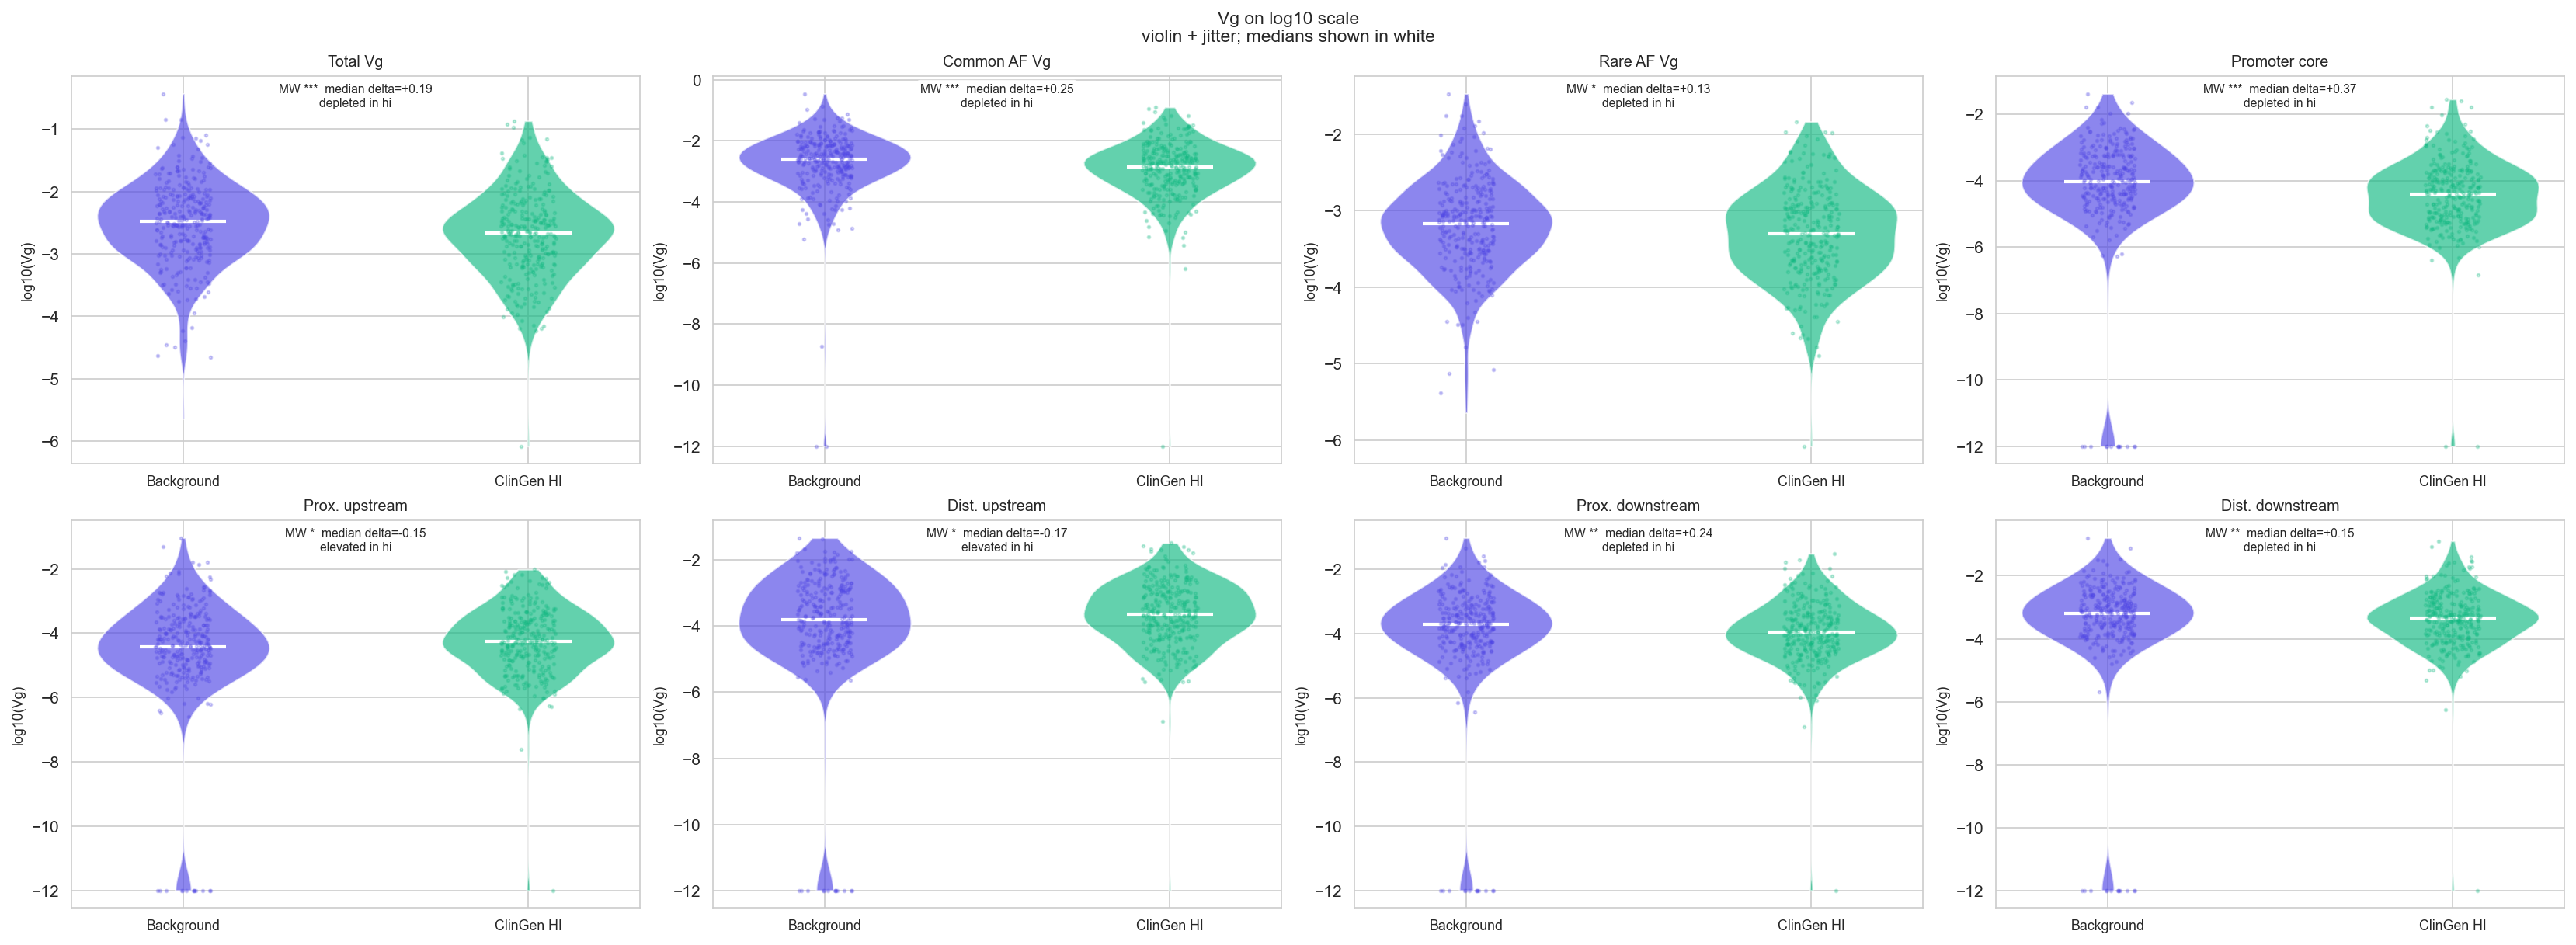

[save_plot] Saved: 02_vg_log_scale_TODO2_AllVgCols_LogScale_Violins_25032026_1059.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_AllVgCols_LogScale_Violins_25032026_1059.svg


<Figure size 960x720 with 0 Axes>

In [16]:
# ── All Vg columns: violin plots on log scale ──────────────────────────────────

PLOT_COLS = [c for c in present_cols if c in df_real.columns]
COL_LABELS = {
    'vg_predicted':         'Total Vg',
    'vg_common':            'Common AF Vg',
    'vg_rare':              'Rare AF Vg',
    'vg_promoter_core':     'Promoter core',
    'vg_proximal_upstream': 'Prox. upstream',
    'vg_distal_upstream':   'Dist. upstream',
    'vg_down_proximal':     'Prox. downstream',
    'vg_down_distal':       'Dist. downstream',
}

ncols = 4
nrows = (len(PLOT_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), constrained_layout=True)
axes_flat = np.array(axes).flatten()

for ax, col in zip(axes_flat, PLOT_COLS):
    sub_bg = df_bg.select(col).to_pandas()[col].dropna().values
    sub_hi = df_hi.select(col).to_pandas()[col].dropna().values

    # clip zeros before log transform
    sub_bg_log = np.log10(clip_for_log(sub_bg))
    sub_hi_log = np.log10(clip_for_log(sub_hi))

    plot_data = [sub_bg_log, sub_hi_log]
    positions = [0, 1]
    colors    = [SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']]

    vp = ax.violinplot(plot_data, positions=positions, showmedians=True, showextrema=False)
    for patch, color in zip(vp['bodies'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    vp['cmedians'].set_colors(['white', 'white'])
    vp['cmedians'].set_linewidth(2.0)

    # Overlay raw jitter
    for idx, (vals, color) in enumerate(zip(plot_data, colors)):
        jitter = np.random.default_rng(idx).uniform(-0.08, 0.08, size=min(300, len(vals)))
        sub_sample = np.random.default_rng(idx + 10).choice(vals, min(300, len(vals)), replace=False)
        ax.scatter(idx + jitter, sub_sample, s=3, alpha=0.25, color=color, zorder=2)

    # align the one-tailed test with the observed direction
    delta_log = np.median(sub_bg_log) - np.median(sub_hi_log)
    if delta_log >= 0:
        _, p_mw = stats.mannwhitneyu(sub_bg, sub_hi, alternative='greater')
        direction = 'depleted in hi'
    else:
        _, p_mw = stats.mannwhitneyu(sub_hi, sub_bg, alternative='greater')
        direction = 'elevated in hi'

    sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Background', 'ClinGen HI'], fontsize=8.5)
    ax.set_ylabel('log10(Vg)', fontsize=8.5)
    ax.set_title(COL_LABELS.get(col, col), fontsize=9.5)
    ax.text(
        0.5,
        0.98,
        f'MW {sig}  median delta={delta_log:+.2f}\n{direction}',
        transform=ax.transAxes,
        fontsize=7.5,
        ha='center',
        va='top',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85),
    )

for ax in axes_flat[len(PLOT_COLS):]:
    ax.set_visible(False)

fig.suptitle(
    'Vg on log10 scale\n'
    'violin + jitter; medians shown in white',
    fontsize=11,
)

with autosave('TODO2_AllVgCols_LogScale_Violins', notebook=NOTEBOOK_NAME):
    plt.show()

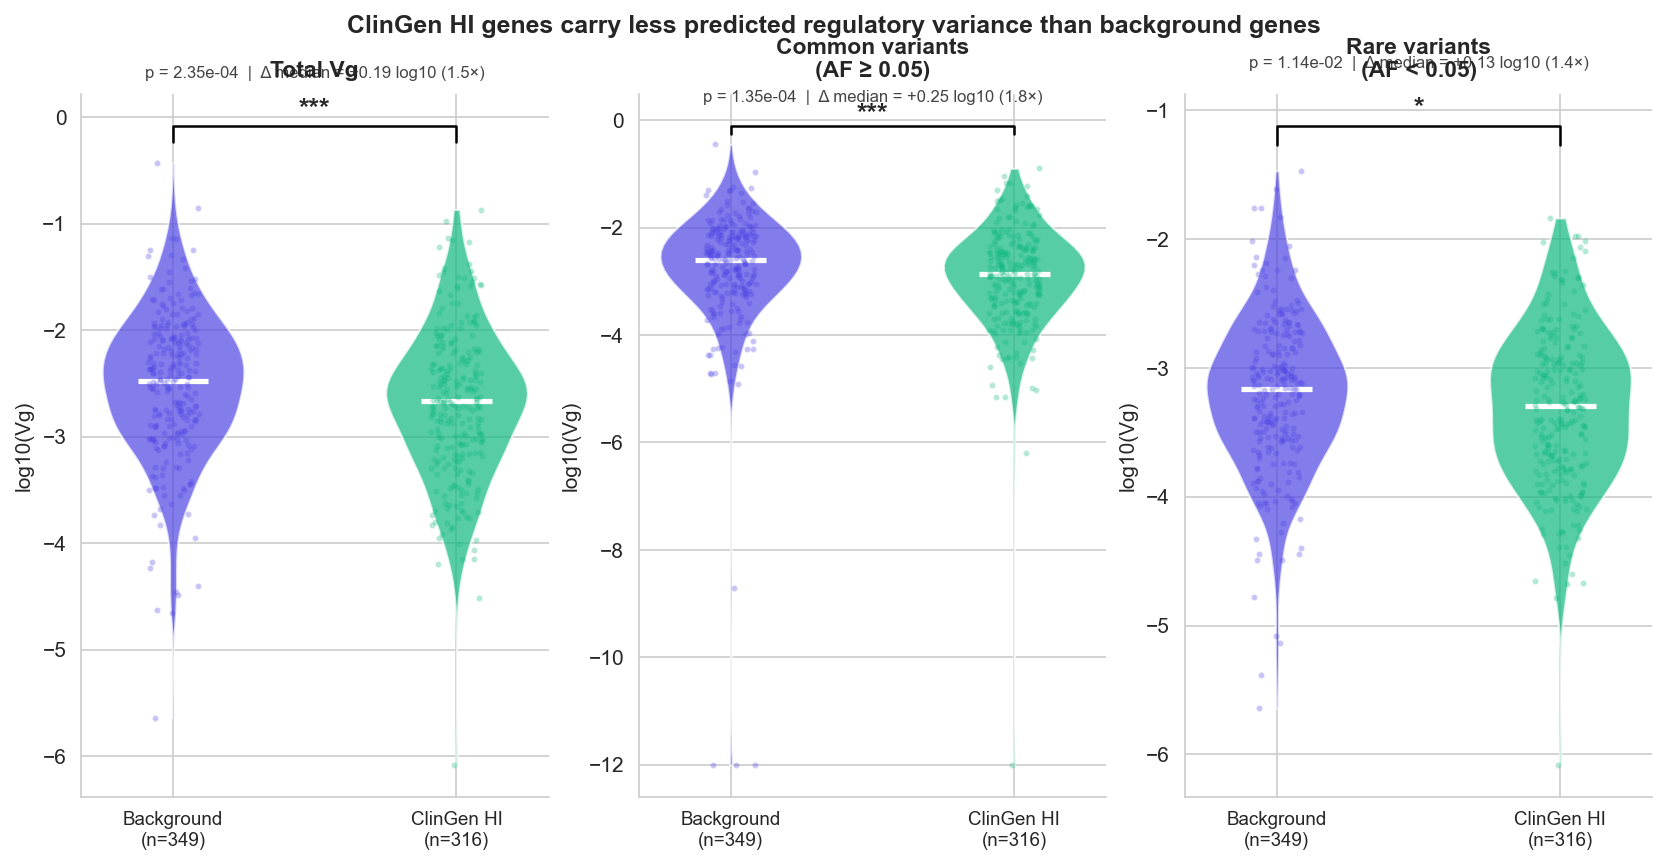

[save_plot] Saved: 02_vg_log_scale_SLIDE4A_Vg_Depletion_Overview_25032026_1059.pdf
[save_plot] Saved: 02_vg_log_scale_SLIDE4A_Vg_Depletion_Overview_25032026_1059.svg


<Figure size 960x720 with 0 Axes>

In [17]:
# ── SLIDE 4A: Total / Common / Rare Vg — overall depletion in HI genes ────────

OVERVIEW_COLS = [
    ('vg_predicted', 'Total Vg'),
    ('vg_common',    'Common variants\n(AF ≥ 0.05)'),
    ('vg_rare',      'Rare variants\n(AF < 0.05)'),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

for ax, (col, label) in zip(axes, OVERVIEW_COLS):
    hi_v = df_hi.select(col).to_pandas()[col].dropna().values
    bg_v = df_bg.select(col).to_pandas()[col].dropna().values

    hi_log = np.log10(clip_for_log(hi_v))
    bg_log = np.log10(clip_for_log(bg_v))

    colors = [SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']]
    vp = ax.violinplot([bg_log, hi_log], positions=[0, 1], showmedians=True, showextrema=False)
    for patch, color in zip(vp['bodies'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.70)
    vp['cmedians'].set_colors(['white', 'white'])
    vp['cmedians'].set_linewidth(2.5)

    rng = np.random.default_rng(42)
    for idx, (vals, color) in enumerate(zip([bg_log, hi_log], colors)):
        n = min(250, len(vals))
        sub = rng.choice(vals, n, replace=False)
        jitter = rng.uniform(-0.09, 0.09, size=n)
        ax.scatter(idx + jitter, sub, s=4, alpha=0.22, color=color, zorder=2)

    # One-tailed MW: BG > HI (depletion hypothesis)
    _, p_dep = stats.mannwhitneyu(bg_v, hi_v, alternative='greater')
    delta = np.median(bg_log) - np.median(hi_log)
    fold  = 10 ** delta
    sig = '***' if p_dep < 0.001 else ('**' if p_dep < 0.01 else ('*' if p_dep < 0.05 else 'ns'))

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Background\n(n={len(bg_v)})', f'ClinGen HI\n(n={len(hi_v)})'], fontsize=9)
    ax.set_ylabel('log10(Vg)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

    y_top = max(bg_log.max(), hi_log.max())
    y_br  = y_top + 0.35
    ax.plot([0, 0, 1, 1], [y_br - 0.15, y_br, y_br, y_br - 0.15], color='black', lw=1.2)
    ax.text(0.5, y_br + 0.08, sig, ha='center', fontsize=13, fontweight='bold')
    ax.text(0.5, y_br + 0.45,
            f'p = {p_dep:.2e}  |  Δ median = {delta:+.2f} log10 ({fold:.1f}×)',
            ha='center', fontsize=8, color='#444')

fig.suptitle(
    'ClinGen HI genes carry less predicted regulatory variance than background genes',
    fontsize=12, fontweight='bold', y=1.02,
)

with autosave('SLIDE4A_Vg_Depletion_Overview', notebook=NOTEBOOK_NAME):
    plt.show()


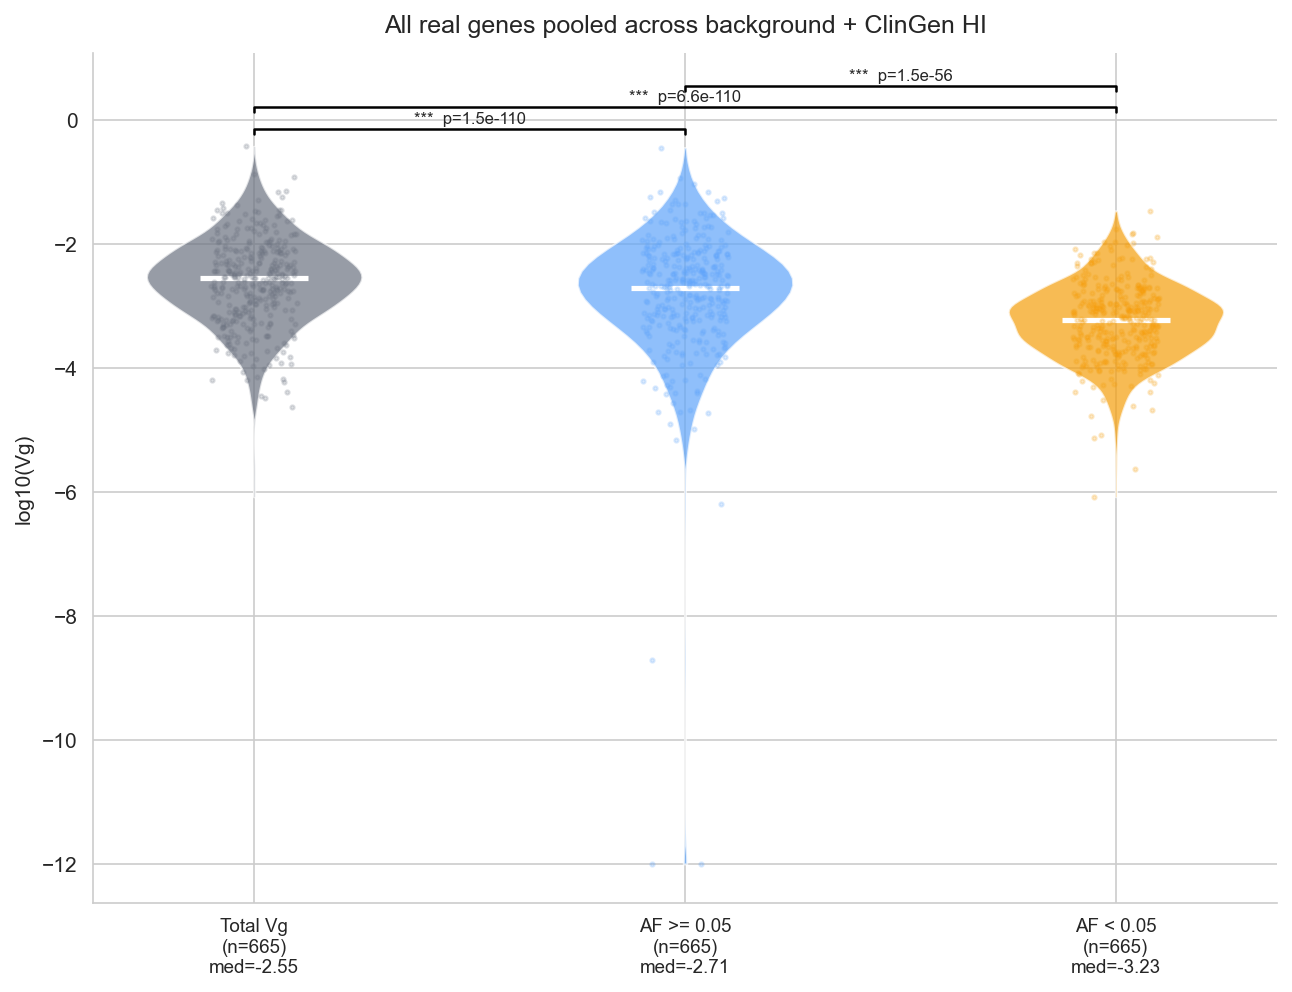

[save_plot] Saved: 02_vg_log_scale_TODO2_AllGenes_TotalVsAFBins_Pooled_25032026_1104.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_AllGenes_TotalVsAFBins_Pooled_25032026_1104.svg


<Figure size 960x720 with 0 Axes>

In [20]:
# ── pooled all genes: total vs af bins on log scale ─────────────────────────────

POOLED_AF_COLS = [
    ('vg_predicted', 'Total Vg'),
    ('vg_common', 'AF >= 0.05'),
    ('vg_rare', 'AF < 0.05'),
]

PAIRWISE_COMPARISONS = [(0, 1), (0, 2), (1, 2)]


def _format_p_value(p_value: float) -> str:
    """format a compact p-value label.

    args:
        p_value (float): pairwise test p-value.

    returns:
        str: formatted label with stars and p-value.
    """
    if p_value < 0.001:
        stars = '***'
    elif p_value < 0.01:
        stars = '**'
    elif p_value < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    return f'{stars}  p={p_value:.1e}'


missing_cols = [col for col, _ in POOLED_AF_COLS if col not in df_real.columns]
if missing_cols:
    raise ValueError(f'missing required columns: {missing_cols}')

plot_data = []
tick_labels = []
colors = ['#6b7280', '#60a5fa', '#f59e0b']

for col, label in POOLED_AF_COLS:
    vals = df_real.select(col).to_pandas()[col].dropna().values
    vals_log = np.log10(clip_for_log(vals))
    plot_data.append(vals_log)
    tick_labels.append(f'{label}\n(n={len(vals)})\nmed={np.median(vals_log):.2f}')

fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), constrained_layout=True)
rng = np.random.default_rng(7)

with autosave('TODO2_AllGenes_TotalVsAFBins_Pooled', notebook=NOTEBOOK_NAME):
    vp = ax.violinplot(
        plot_data,
        positions=np.arange(len(plot_data)),
        showmedians=True,
        showextrema=False,
    )
    for patch, color in zip(vp['bodies'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.70)
    vp['cmedians'].set_colors(['white'] * len(plot_data))
    vp['cmedians'].set_linewidth(2.5)

    # keep the pooled panel visually comparable to the split-source panels
    for idx, (vals, color) in enumerate(zip(plot_data, colors)):
        n = min(350, len(vals))
        sub = rng.choice(vals, n, replace=False)
        jitter = rng.uniform(-0.10, 0.10, size=n)
        ax.scatter(idx + jitter, sub, s=4, alpha=0.22, color=color, zorder=2)

    y_top = max(np.max(vals) for vals in plot_data)
    y_step = 0.35
    bracket_height = 0.08
    label_offset = 0.04

    for level, (left_idx, right_idx) in enumerate(PAIRWISE_COMPARISONS):
        left_col = POOLED_AF_COLS[left_idx][0]
        right_col = POOLED_AF_COLS[right_idx][0]
        pair_df = df_real.select([left_col, right_col]).drop_nulls().to_pandas()
        left_log = np.log10(clip_for_log(pair_df[left_col].values))
        right_log = np.log10(clip_for_log(pair_df[right_col].values))
        _, p_value = stats.wilcoxon(left_log, right_log, alternative='two-sided')

        y_bracket = y_top + 0.20 + (level * y_step)
        ax.plot(
            [left_idx, left_idx, right_idx, right_idx],
            [y_bracket, y_bracket + bracket_height, y_bracket + bracket_height, y_bracket],
            color='black',
            lw=1.2,
        )
        ax.text(
            (left_idx + right_idx) / 2,
            y_bracket + bracket_height + label_offset,
            _format_p_value(p_value),
            ha='center',
            va='bottom',
            fontsize=8,
        )

    ax.set_xticks(np.arange(len(plot_data)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylabel('log10(Vg)', fontsize=10)
    ax.set_title('All real genes pooled across background + ClinGen HI', fontsize=12, pad=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(top=y_top + 0.20 + (len(PAIRWISE_COMPARISONS) * y_step) + 0.25)

    plt.show()


[save_plot] Saved: 02_vg_log_scale_TODO2_SpatialGradient_Vg_Windows_25032026_1059.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_SpatialGradient_Vg_Windows_25032026_1059.svg


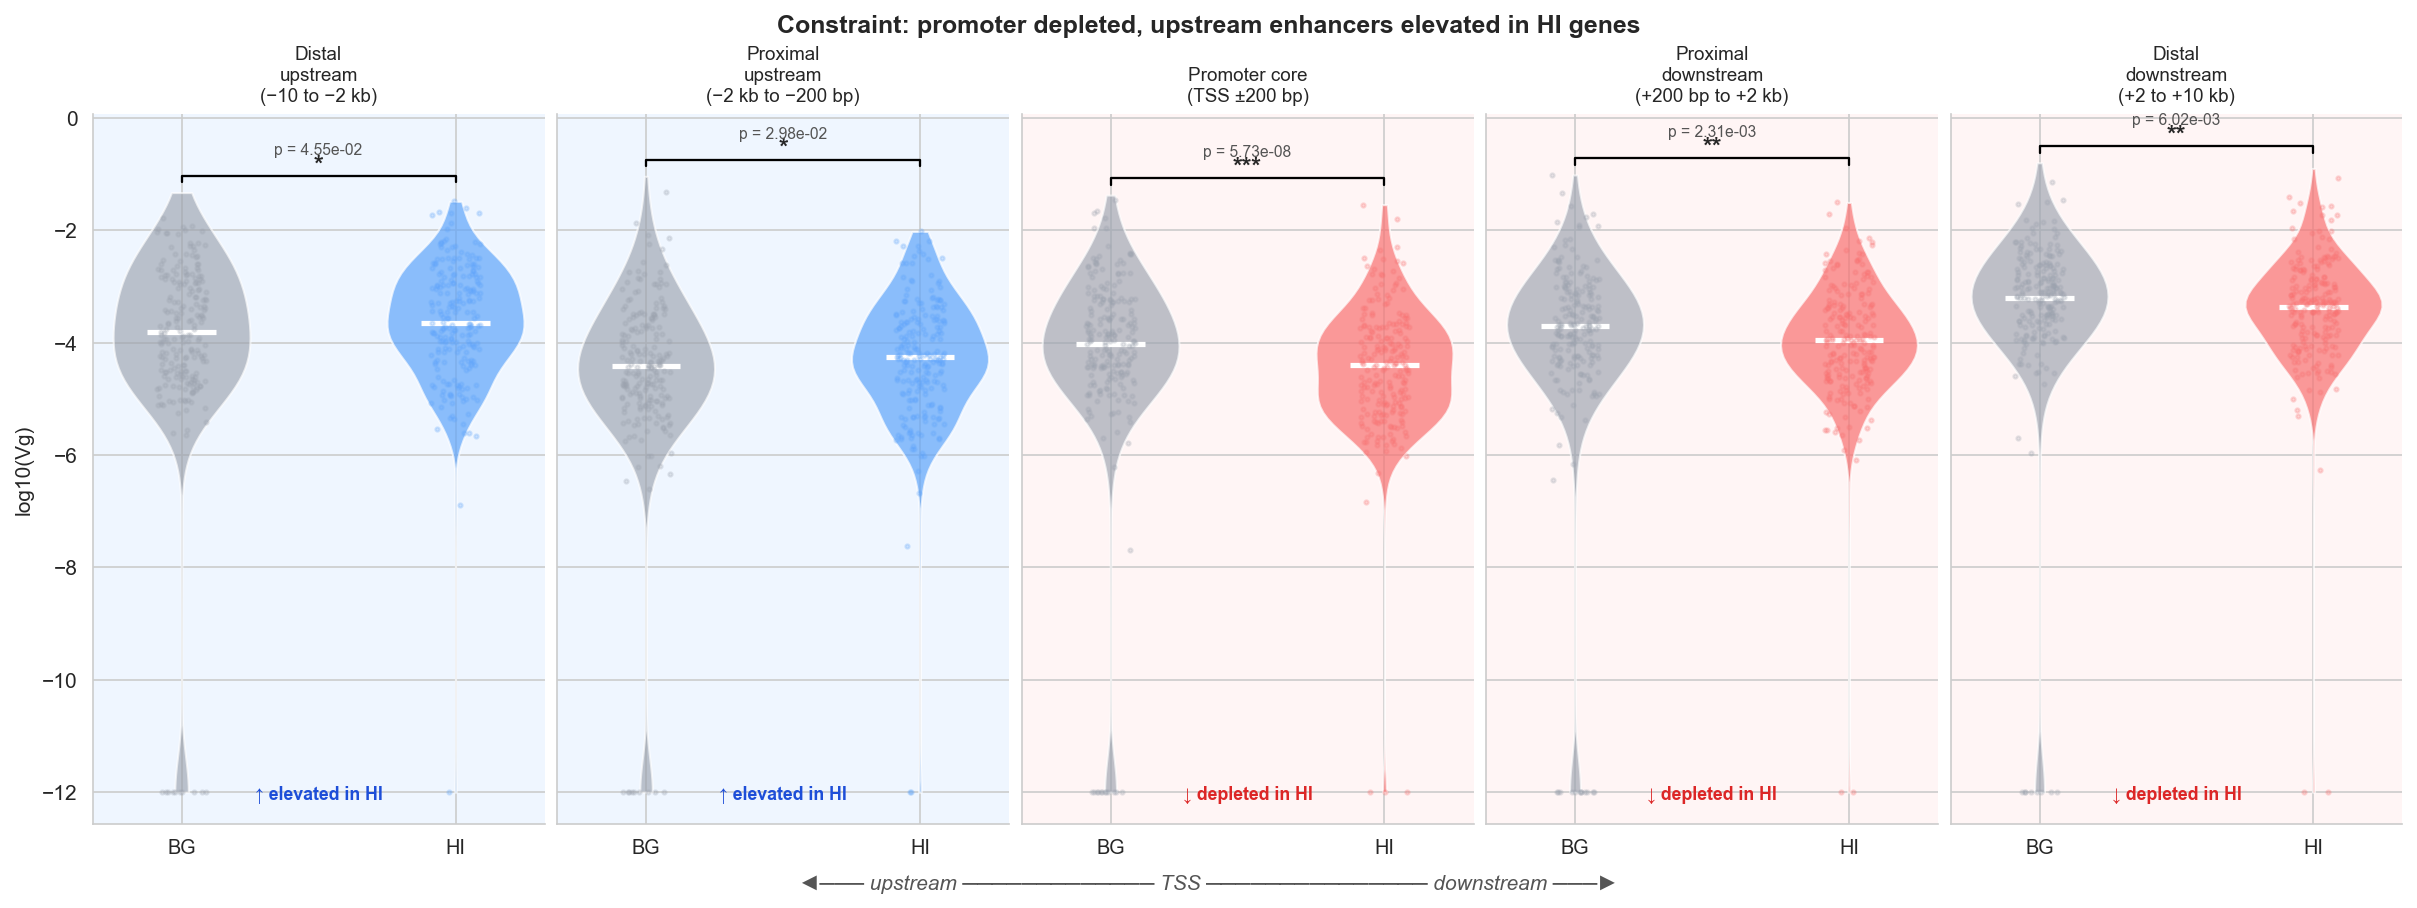

In [18]:
# ── SLIDE 4B: Spatial gradient — 5 windows ordered from upstream to downstream ──

SPATIAL_WINDOWS = [
    ('vg_distal_upstream',   'Distal\nupstream\n(−10 to −2 kb)',        False),
    ('vg_proximal_upstream', 'Proximal\nupstream\n(−2 kb to −200 bp)',  False),
    ('vg_promoter_core',     'Promoter core\n(TSS ±200 bp)',            True),
    ('vg_down_proximal',     'Proximal\ndownstream\n(+200 bp to +2 kb)',True),
    ('vg_down_distal',       'Distal\ndownstream\n(+2 to +10 kb)',      True),
]

C_DEPLETED = '#f87171'
C_ELEVATED = '#60a5fa'
C_BG       = '#9ca3af'

fig, axes = plt.subplots(1, 5, figsize=(16, 5.5), constrained_layout=True, sharey=True)
rng = np.random.default_rng(0)

with autosave('TODO2_SpatialGradient_Vg_Windows', notebook=NOTEBOOK_NAME):

    for ax, (col, label, depleted) in zip(axes, SPATIAL_WINDOWS):
        hi_v = df_hi.select(col).to_pandas()[col].dropna().values
        bg_v = df_bg.select(col).to_pandas()[col].dropna().values
        hi_log = np.log10(clip_for_log(hi_v))
        bg_log = np.log10(clip_for_log(bg_v))
        hi_color = C_DEPLETED if depleted else C_ELEVATED

        vp = ax.violinplot([bg_log, hi_log], positions=[0, 1], showmedians=True, showextrema=False)
        vp['bodies'][0].set_facecolor(C_BG);      vp['bodies'][0].set_alpha(0.65)
        vp['bodies'][1].set_facecolor(hi_color);  vp['bodies'][1].set_alpha(0.70)
        vp['cmedians'].set_colors(['white', 'white'])
        vp['cmedians'].set_linewidth(2.5)

        for idx, (vals, color) in enumerate(zip([bg_log, hi_log], [C_BG, hi_color])):
            n   = min(220, len(vals))
            sub = rng.choice(vals, n, replace=False)
            jit = rng.uniform(-0.09, 0.09, size=n)
            ax.scatter(idx + jit, sub, s=4, alpha=0.25, color=color, zorder=2)

        if depleted:
            _, p_mw = stats.mannwhitneyu(bg_v, hi_v, alternative='greater')
            dir_txt, dir_color = '↓ depleted in HI', '#dc2626'
        else:
            _, p_mw = stats.mannwhitneyu(hi_v, bg_v, alternative='greater')
            dir_txt, dir_color = '↑ elevated in HI', '#1d4ed8'

        sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['BG', 'HI'], fontsize=9.5)
        ax.set_title(label, fontsize=9, pad=6)
        ax.spines[['top', 'right']].set_visible(False)
        if ax == axes[0]:
            ax.set_ylabel('log10(Vg)', fontsize=10)

        y_top = max(bg_log.max(), hi_log.max())
        y_br  = y_top + 0.30
        ax.plot([0, 0, 1, 1], [y_br - 0.12, y_br, y_br, y_br - 0.12], color='black', lw=1.1)
        ax.text(0.5, y_br + 0.07, sig, ha='center', fontsize=12, fontweight='bold')
        ax.text(0.5, y_br + 0.38, f'p = {p_mw:.2e}', ha='center', fontsize=7.5, color='#555')
        ax.text(0.5, 0.03, dir_txt, ha='center', va='bottom',
                transform=ax.transAxes, fontsize=8.5, fontweight='bold', color=dir_color)
        ax.set_facecolor('#fff5f5' if depleted else '#eff6ff')

    fig.text(0.5, -0.03,
            '◄─── upstream ───────────── TSS ─────────────── downstream ───►',
            ha='center', fontsize=10, style='italic', color='#555')
    fig.suptitle(
        'Constraint: promoter depleted, upstream enhancers elevated in HI genes',
        fontsize=12, fontweight='bold', y=1.03,
    )

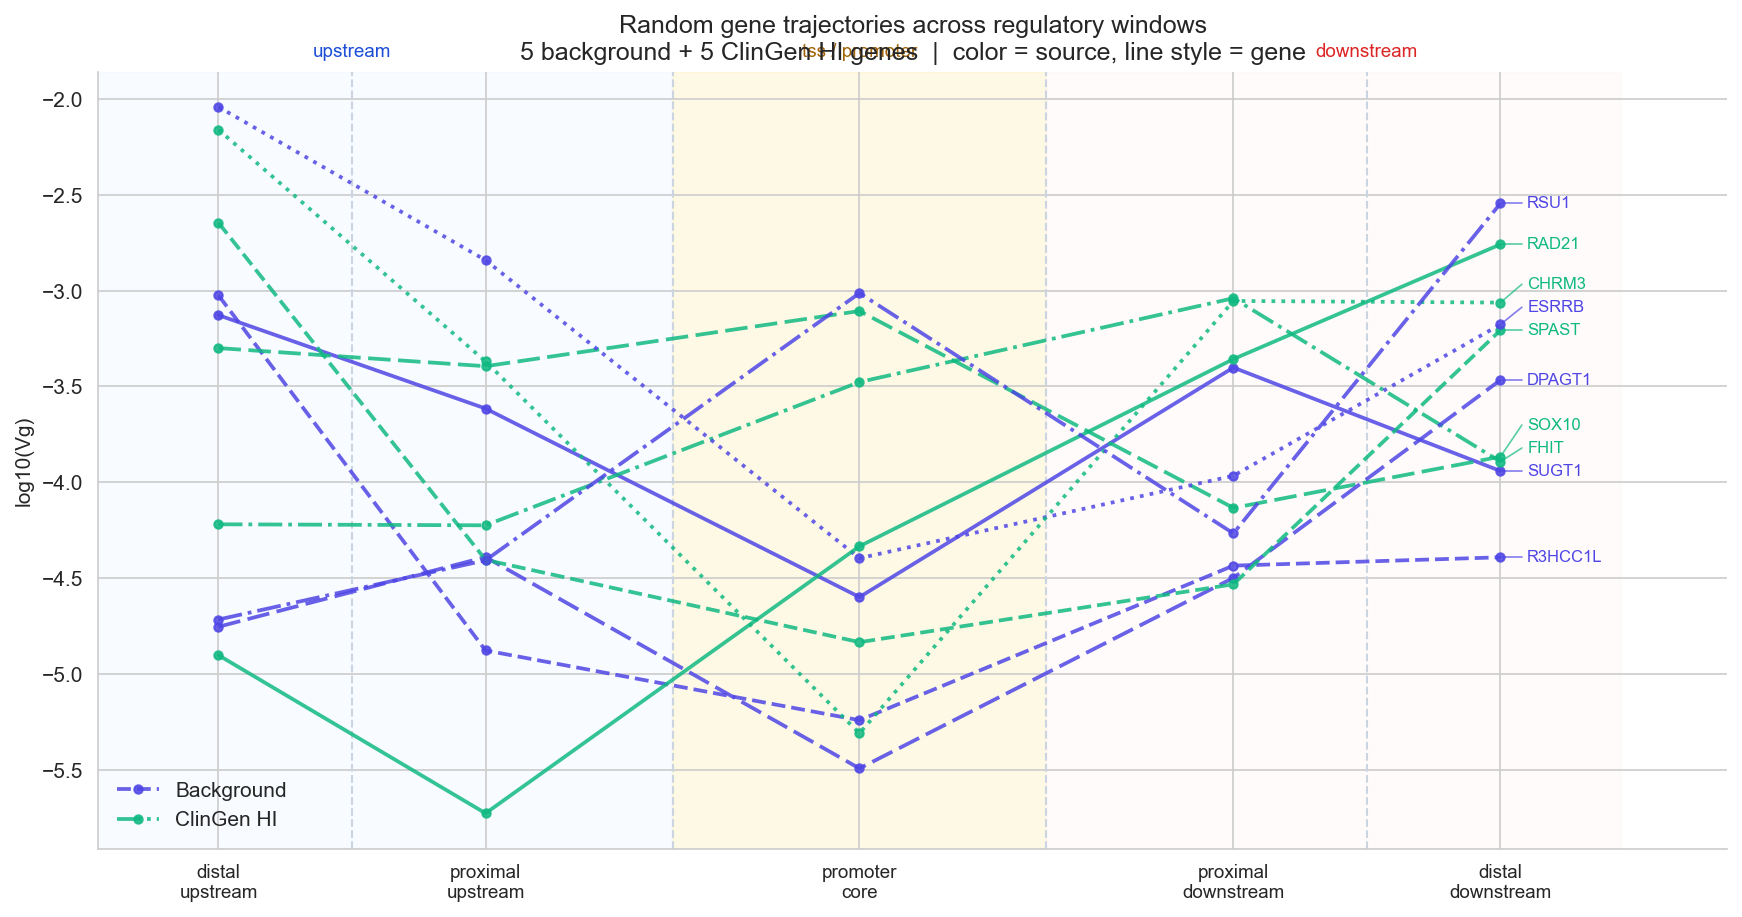

[save_plot] Saved: 02_vg_log_scale_TODO2_SpatialGradient_10Gene_Trajectories_25032026_1136.pdf
[save_plot] Saved: 02_vg_log_scale_TODO2_SpatialGradient_10Gene_Trajectories_25032026_1136.svg


<Figure size 960x720 with 0 Axes>

In [ ]:
# ── companion plot: 3 + 3 gene trajectories with all-gene trends ───────────────

TRAJECTORY_WINDOWS = [
    ('vg_distal_upstream', 'distal\nupstream'),
    ('vg_proximal_upstream', 'proximal\nupstream'),
    ('vg_promoter_core', 'promoter\ncore'),
    ('vg_down_proximal', 'proximal\ndownstream'),
    ('vg_down_distal', 'distal\ndownstream'),
]

trajectory_cols = [col for col, _ in TRAJECTORY_WINDOWS]
trajectory_df = (
    df_real
    .select(['gene_id', 'gene_symbol', 'source', *trajectory_cols])
    .drop_nulls(['gene_id', 'source', *trajectory_cols])
    .to_pandas()
)

bg_genes = trajectory_df[trajectory_df['source'] == 'background'].copy()
hi_genes = trajectory_df[trajectory_df['source'] == 'clingen'].copy()

sample_per_source = 3
line_styles = ['-', '--', ':']

if len(bg_genes) < sample_per_source or len(hi_genes) < sample_per_source:
    raise ValueError(
        f'not enough complete genes to sample {sample_per_source} background and {sample_per_source} clingen genes'
    )

rng = np.random.default_rng(11)
sampled_bg = bg_genes.iloc[rng.choice(len(bg_genes), size=sample_per_source, replace=False)].copy()
sampled_hi = hi_genes.iloc[rng.choice(len(hi_genes), size=sample_per_source, replace=False)].copy()
sampled_bg['line_style'] = line_styles[:sample_per_source]
sampled_hi['line_style'] = line_styles[:sample_per_source]
sampled_genes = pd.concat([sampled_bg, sampled_hi], ignore_index=True)

sampled_genes['display_name'] = sampled_genes['gene_symbol'].fillna(sampled_genes['gene_id'])
sampled_genes['end_y'] = sampled_genes['vg_down_distal'].map(lambda value: np.log10(clip_for_log(np.array([value])))[0])
sampled_genes = sampled_genes.sort_values(['end_y', 'display_name']).reset_index(drop=True)

label_y_positions = []
min_sep = 0.12
for end_y in sampled_genes['end_y']:
    if not label_y_positions:
        label_y_positions.append(end_y)
        continue
    label_y_positions.append(max(end_y, label_y_positions[-1] + min_sep))

sampled_genes['label_y'] = label_y_positions
x_positions = np.array([0.0, 1.0, 2.4, 3.8, 4.8])
window_boundaries = (x_positions[:-1] + x_positions[1:]) / 2

fig, ax = plt.subplots(1, 1, figsize=(11.5, 6), constrained_layout=True)

with autosave('TODO2_SpatialGradient_10Gene_Trajectories', notebook=NOTEBOOK_NAME):
    ax.axvspan(-0.45, window_boundaries[1], color='#eff6ff', alpha=0.40, zorder=0)
    ax.axvspan(window_boundaries[1], window_boundaries[2], color='#fef3c7', alpha=0.45, zorder=0)
    ax.axvspan(window_boundaries[2], x_positions[-1] + 0.45, color='#fff5f5', alpha=0.40, zorder=0)

    for boundary in window_boundaries:
        ax.axvline(boundary, color='#cbd5e1', lw=1.0, ls='--', zorder=1)

    for source_name, source_df in [('background', bg_genes), ('clingen', hi_genes)]:
        values_log = np.log10(clip_for_log(source_df[trajectory_cols].to_numpy(dtype=float)))
        q25 = np.percentile(values_log, 25, axis=0)
        median = np.median(values_log, axis=0)
        q75 = np.percentile(values_log, 75, axis=0)
        color = SOURCE_PALETTE[source_name]
        display_name = 'Background' if source_name == 'background' else 'ClinGen HI'

        ax.fill_between(x_positions, q25, q75, color=color, alpha=0.12, zorder=1)
        ax.plot(
            x_positions,
            median,
            color=color,
            lw=3.0,
            alpha=0.95,
            zorder=3,
            label=f'{display_name} median with IQR',
        )

    for _, row in sampled_genes.iterrows():
        y_values = np.log10(clip_for_log(row[trajectory_cols].to_numpy(dtype=float)))
        color = SOURCE_PALETTE[row['source']]

        ax.plot(
            x_positions,
            y_values,
            marker='o',
            ms=4,
            lw=1.6,
            ls=row['line_style'],
            alpha=0.75,
            color=color,
            zorder=2,
        )
        ax.text(
            x_positions[-1] + 0.10,
            row['label_y'],
            row['display_name'],
            fontsize=8,
            va='center',
            color=color,
        )
        ax.plot(
            [x_positions[-1], x_positions[-1] + 0.08],
            [y_values[-1], row['label_y']],
            color=color,
            lw=0.8,
            alpha=0.7,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([label for _, label in TRAJECTORY_WINDOWS], fontsize=9)
    ax.set_ylabel('log10(Vg)', fontsize=10)
    ax.set_title(
        'Example gene trajectories with all-gene source trends\n'
        '3 background + 3 ClinGen HI genes  |  thick lines = source median, ribbons = IQR',
        fontsize=12,
    )
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='lower left')
    ax.set_xlim(-0.45, x_positions[-1] + 0.85)

    ax.text(np.mean(x_positions[:2]), 1.02, 'upstream', transform=ax.get_xaxis_transform(), ha='center', fontsize=9, color='#1d4ed8')
    ax.text(x_positions[2], 1.02, 'tss / promoter', transform=ax.get_xaxis_transform(), ha='center', fontsize=9, color='#a16207')
    ax.text(np.mean(x_positions[3:]), 1.02, 'downstream', transform=ax.get_xaxis_transform(), ha='center', fontsize=9, color='#dc2626')

    plt.show()
